<a href="https://colab.research.google.com/github/falvarezaguiar/Vision_Artificial_Casos_Industriales/blob/main/vision_inspection_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inspección Visual Industrial con CNN

**Replicación del experimento de Ingo Nowitzky**

**Artículo:** [Building a Vision Inspection CNN for an Industrial Application](https://medium.com/data-science/building-a-vision-inspection-cnn-for-an-industrial-application-138936d7a34a)

**Autor:** Ingo Nowitzky (Nov 2024)

---

## Objetivo

Clasificar componentes electrónicos (bobinas con pines metálicos) como:
- **OK (1_io):** Pines correctamente alineados
- **NOK (0_nio):** Pines doblados/defectuosos

## Dataset

- **Total:** 624 imágenes BMP grayscale (400x700 px)
- **Distribución:** 500 OK + 124 NOK
- **Split (según artículo):** 50% train / 30% val / 20% test
  - Train: ~312 imágenes (50%)
  - Val: ~187 imágenes (30%)
  - Test: ~125 imágenes (20%)

## Arquitectura CNN

```
Input: 1x400x700
├─ Conv2d(1→6, k=5) + ReLU + MaxPool(2)
├─ Conv2d(6→16, k=5) + ReLU + MaxPool(2)
├─ Flatten → 266,944 valores
├─ Linear(266944→120) + ReLU
└─ Linear(120→2) → [NOK, OK]

Total: 32M parámetros
```

## Hiperparámetros

- Épocas: 60
- Batch size: 4
- Learning rate: 0.001
- Optimizer: SGD
- **Objetivo:** Val Accuracy > 95%

---


## 1. Setup - Montar Drive y Verificar GPU


In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Cambiar al directorio del proyecto
%cd /content/drive/MyDrive/PF1-VA

# Verificar estructura
!ls -la


/content/drive/MyDrive/PF1-VA
total 16
drwx------ 2 root root 4096 Nov 17 15:05 checkpoints
drwx------ 2 root root 4096 Nov  9 21:49 data
drwx------ 2 root root 4096 Nov 17 15:18 models
drwx------ 2 root root 4096 Nov 17 15:14 notebooks


In [ ]:
# Verificar GPU disponible
import torch

print("="*70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Memory: {mem_gb:.2f} GB")
else:
    print("\nADVERTENCIA: GPU no disponible")
    print("   Runtime -> Change runtime type -> GPU")

print("="*70)


PyTorch version: 2.8.0+cu126
CUDA disponible: False

ADVERTENCIA: GPU no disponible
   Runtime -> Change runtime type -> GPU


## 2. Exploración del Dataset


In [ ]:
# Verificar estructura del dataset
import os
from pathlib import Path

data_dir = Path('data/Coil_Vision')

print("\nEstructura del Dataset:")
print("="*70)

# Dataset original
original_dir = data_dir / '01_train_val_test'
if original_dir.exists():
    nok_files = list((original_dir / '0_nio').glob('*.bmp'))
    ok_files = list((original_dir / '1_io').glob('*.bmp'))
    print(f"\nDataset original:")
    print(f"  NOK (0_nio): {len(nok_files)} imagenes")
    print(f"  OK (1_io): {len(ok_files)} imagenes")
    print(f"  Total: {len(nok_files) + len(ok_files)} imagenes")

# Verificar si ya esta dividido (train/val/test)
train_dir = data_dir / 'train'
val_dir = data_dir / 'val'
test_dir = data_dir / 'test'

if train_dir.exists() and val_dir.exists() and test_dir.exists():
    train_nok = len(list((train_dir / '0_nio').glob('*.bmp')))
    train_ok = len(list((train_dir / '1_io').glob('*.bmp')))
    val_nok = len(list((val_dir / '0_nio').glob('*.bmp')))
    val_ok = len(list((val_dir / '1_io').glob('*.bmp')))
    test_nok = len(list((test_dir / '0_nio').glob('*.bmp')))
    test_ok = len(list((test_dir / '1_io').glob('*.bmp')))

    total = train_nok + train_ok + val_nok + val_ok + test_nok + test_ok

    print(f"\n[OK] Dataset dividido segun articulo (50/30/20):")
    print(f"  Train: {train_nok} NOK + {train_ok} OK = {train_nok + train_ok} ({(train_nok+train_ok)/total*100:.1f}%)")
    print(f"  Val:   {val_nok} NOK + {val_ok} OK = {val_nok + val_ok} ({(val_nok+val_ok)/total*100:.1f}%)")
    print(f"  Test:  {test_nok} NOK + {test_ok} OK = {test_nok + test_ok} ({(test_nok+test_ok)/total*100:.1f}%)")
else:
    print(f"\n[!] Dataset NO dividido - ejecuta siguiente celda")

print("="*70)



Estructura del Dataset:

Dataset original:
  NOK (0_nio): 124 imagenes
  OK (1_io): 500 imagenes
  Total: 624 imagenes

[!] Dataset NO dividido - ejecuta siguiente celda


In [ ]:
# Dividir dataset en train/val/test (50/30/20)
# Segun articulo de Ingo Nowitzky seccion 2.4

import shutil
import random

def split_dataset(source_dir='data/Coil_Vision/01_train_val_test',
                  output_base='data/Coil_Vision',
                  train_ratio=0.5,
                  val_ratio=0.3,
                  test_ratio=0.2,
                  seed=42):
    """
    Divide dataset en train/val/test segun articulo de Ingo

    Split del articulo (seccion 2.4):
    - 50% training data
    - 30% validation data
    - 20% testing data
    """

    random.seed(seed)

    # Crear directorios para los 3 splits
    train_dir = os.path.join(output_base, 'train')
    val_dir = os.path.join(output_base, 'val')
    test_dir = os.path.join(output_base, 'test')
    classes = ['0_nio', '1_io']

    for split_dir in [train_dir, val_dir, test_dir]:
        for class_name in classes:
            os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

    # Procesar cada clase
    for class_name in classes:
        class_path = os.path.join(source_dir, class_name)
        images = [f for f in os.listdir(class_path) if f.endswith('.bmp')]
        random.shuffle(images)

        # Calcular splits
        n_total = len(images)
        n_train = int(n_total * train_ratio)
        n_val = int(n_total * val_ratio)
        # test toma el resto para asegurar que usamos todas las imagenes

        train_images = images[:n_train]
        val_images = images[n_train:n_train+n_val]
        test_images = images[n_train+n_val:]

        # Copiar archivos a cada split
        for img in train_images:
            shutil.copy2(os.path.join(class_path, img),
                        os.path.join(train_dir, class_name, img))

        for img in val_images:
            shutil.copy2(os.path.join(class_path, img),
                        os.path.join(val_dir, class_name, img))

        for img in test_images:
            shutil.copy2(os.path.join(class_path, img),
                        os.path.join(test_dir, class_name, img))

        print(f"Clase {class_name}: {n_total} total")
        print(f"  Train: {len(train_images)} ({len(train_images)/n_total*100:.1f}%)")
        print(f"  Val:   {len(val_images)} ({len(val_images)/n_total*100:.1f}%)")
        print(f"  Test:  {len(test_images)} ({len(test_images)/n_total*100:.1f}%)")

    print(f"\n[OK] Dataset dividido segun articulo (50/30/20)")

# Ejecutar split
if not os.path.exists('data/Coil_Vision/train'):
    split_dataset()
else:
    print("[OK] Dataset ya dividido")


Clase 0_nio: 124 total
  Train: 62 (50.0%)
  Val:   37 (29.8%)
  Test:  25 (20.2%)
Clase 1_io: 500 total
  Train: 250 (50.0%)
  Val:   150 (30.0%)
  Test:  100 (20.0%)

[OK] Dataset dividido segun articulo (50/30/20)


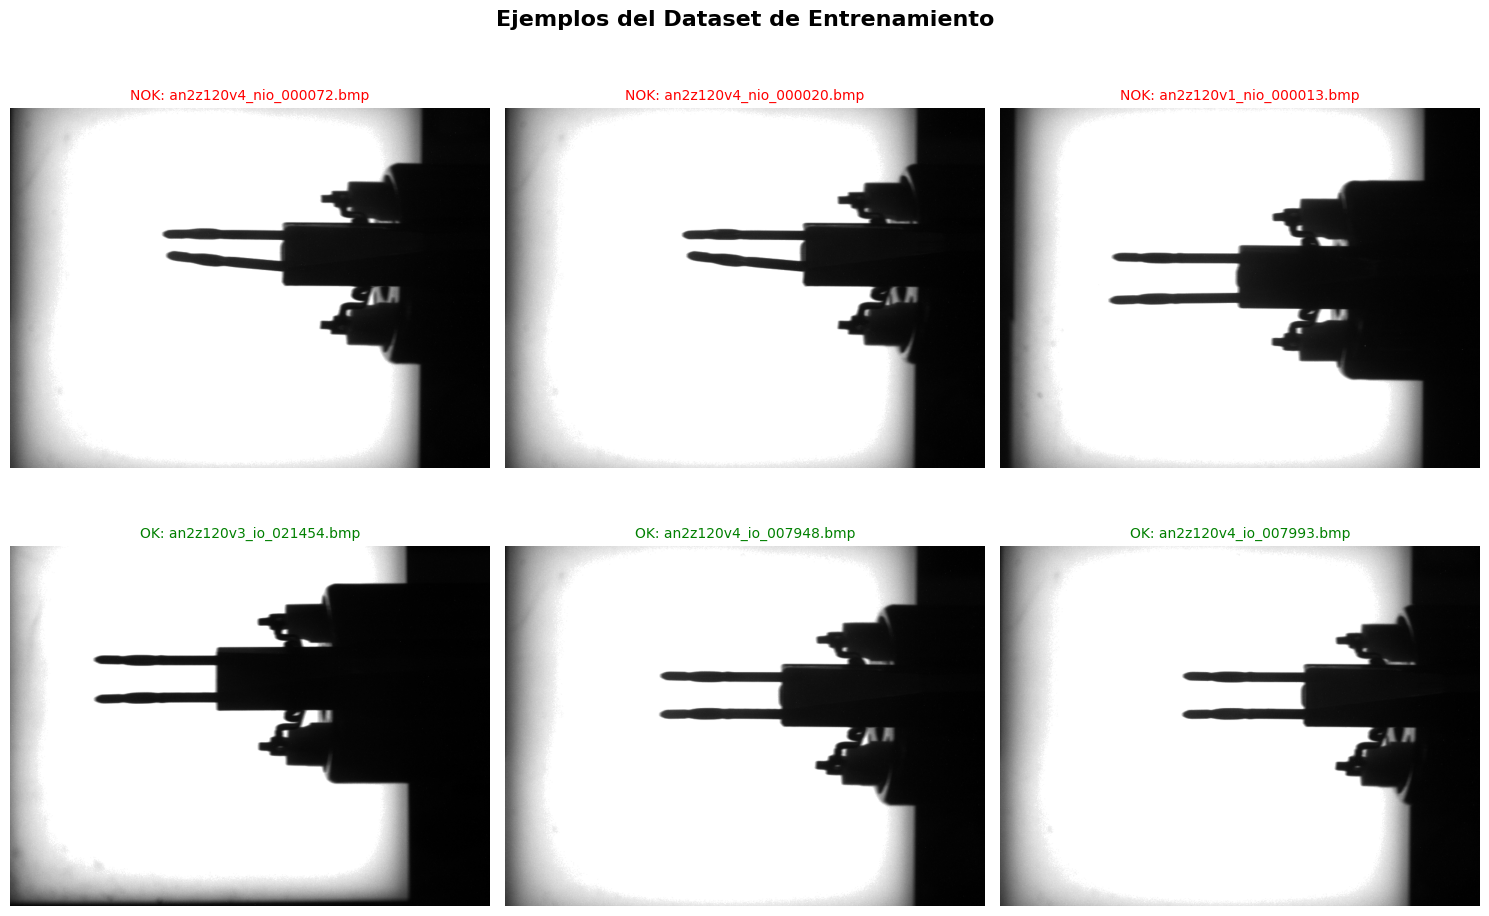

Observa los pines metalicos:
  NOK: Pines doblados o mal alineados
  OK: Pines rectos y correctamente alineados


In [ ]:
# Visualizar ejemplos del dataset
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

train_dir = Path('data/Coil_Vision/train')
nok_images = list((train_dir / '0_nio').glob('*.bmp'))[:3]
ok_images = list((train_dir / '1_io').glob('*.bmp'))[:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Ejemplos del Dataset de Entrenamiento',
             fontsize=16, fontweight='bold')

# Ejemplos NOK (defectuosos)
for i, img_path in enumerate(nok_images):
    img = Image.open(img_path)
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f'NOK: {img_path.name}', fontsize=10, color='red')
    axes[0, i].axis('off')

# Ejemplos OK (buenos)
for i, img_path in enumerate(ok_images):
    img = Image.open(img_path)
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f'OK: {img_path.name}', fontsize=10, color='green')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("Observa los pines metalicos:")
print("  NOK: Pines doblados o mal alineados")
print("  OK: Pines rectos y correctamente alineados")


## 3. Definición del Modelo CNN

Arquitectura exacta del artículo de Ingo Nowitzky


In [ ]:
# Definicion de la arquitectura CNN
import torch.nn as nn

class VisionInspectionCNN(nn.Module):
    """
    CNN para clasificacion binaria de componentes electronicos

    Dimensiones (segun articulo):
    - Input: 1x400x700
    - Conv1 (k=5): 6x396x696
    - MaxPool1 (k=2): 6x198x348
    - Conv2 (k=5): 16x194x344
    - MaxPool2 (k=2): 16x97x172
    - Flatten: 266,944 valores
    - FC1: 120 neuronas
    - FC2: 2 clases (NOK, OK)
    """

    def __init__(self):
        super(VisionInspectionCNN, self).__init__()

        # Capas convolucionales + pooling
        self.model_layers = nn.Sequential(
            # Primera capa convolucional
            nn.Conv2d(in_channels=1, out_channels=6,
                     kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Segunda capa convolucional
            nn.Conv2d(in_channels=6, out_channels=16,
                     kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Capas fully connected
        # Calculo: 16 canales * 97 alto * 172 ancho = 266,944
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 97 * 172, 120),
            nn.ReLU(),
            nn.Linear(120, 2)
        )

    def forward(self, x):
        x = self.model_layers(x)
        x = self.fc_layers(x)
        return x

# Crear instancia y verificar
model = VisionInspectionCNN()
print("Arquitectura del modelo:")
print(model)
print(f"\nParametros totales: {sum(p.numel() for p in model.parameters()):,}")


Arquitectura del modelo:
VisionInspectionCNN(
  (model_layers): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=266944, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=2, bias=True)
  )
)

Parametros totales: 32,036,214


In [ ]:
# Test de forward pass con imagen dummy
dummy_input = torch.randn(1, 1, 400, 700)
output = model(dummy_input)

print("Test de Forward Pass:")
print("="*70)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output logits: {output}")
print("="*70)
print("[OK] Modelo funciona correctamente")


Test de Forward Pass:
Input shape:  torch.Size([1, 1, 400, 700])
Output shape: torch.Size([1, 2])
Output logits: tensor([[ 0.0327, -0.1072]], grad_fn=<AddmmBackward0>)
[OK] Modelo funciona correctamente


## 4. Entrenamiento del Modelo

**Tiempo estimado:** 10-15 minutos con GPU T4

**Hiperparámetros del artículo:**
- Épocas: 60
- Batch size: 4  
- Learning rate: 0.001
- Optimizer: SGD
- Loss: CrossEntropyLoss


In [ ]:
# Preparar datasets y dataloaders
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from collections import Counter

# Transformaciones (segun articulo)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((400, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Cargar datasets
train_dataset = datasets.ImageFolder(
    root='data/Coil_Vision/train',
    transform=transform
)
val_dataset = datasets.ImageFolder(
    root='data/Coil_Vision/val',
    transform=transform
)

print("="*70)
print("DISTRIBUCION DE CLASES EN TRAINING")
print("="*70)

# Calcular distribucion de clases en training
class_counts = Counter([label for _, label in train_dataset])
total = len(train_dataset)
n_classes = len(class_counts)

for class_idx, count in sorted(class_counts.items()):
    class_name = train_dataset.classes[class_idx]
    percentage = count / total * 100
    print(f"  {class_name} (idx {class_idx}): {count} muestras ({percentage:.1f}%)")

print(f"\nTotal: {total} imagenes")
print("="*70)

# Calcular pesos para WeightedRandomSampler (inversamente proporcionales)
# Segun metodo de Ingo Nowitzky
print("\nCALCULANDO PESOS PARA BALANCEO (WeightedRandomSampler)")
print("="*70)

sample_weights = []
for _, label in train_dataset:
    # Peso inversamente proporcional a la frecuencia de la clase
    weight = total / (n_classes * class_counts[label])
    sample_weights.append(weight)

# Mostrar pesos por clase
print("\nPesos calculados por clase:")
for class_idx in sorted(class_counts.keys()):
    class_name = train_dataset.classes[class_idx]
    # Obtener peso de una muestra de esta clase
    example_weight = sample_weights[next(i for i, (_, label) in enumerate(train_dataset) if label == class_idx)]
    print(f"  {class_name}: {example_weight:.3f}")

# Crear WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Permite muestreo con reemplazo para balancear
)

print(f"\n[OK] WeightedRandomSampler creado")
print(f"  Num samples: {len(sample_weights)}")
print(f"  Replacement: True (oversampling de clase minoritaria)")
print("="*70)

# DataLoaders
# Training: usa sampler para balanceo (NO shuffle cuando usas sampler)
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    sampler=sampler  # Usa sampler en vez de shuffle
)

# Validation: NO se balancea (mantiene distribucion real)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print(f"\nDataLoaders creados:")
print(f"  Train loader: {len(train_loader)} batches (con balanceo)")
print(f"  Val loader: {len(val_loader)} batches (sin balanceo - distribucion real)")
print(f"  Clases: {train_dataset.classes}")
print(f"  Mapeo: {train_dataset.class_to_idx}")


DISTRIBUCION DE CLASES EN TRAINING
  0_nio (idx 0): 62 muestras (19.9%)
  1_io (idx 1): 250 muestras (80.1%)

Total: 312 imagenes

CALCULANDO PESOS PARA BALANCEO (WeightedRandomSampler)

Pesos calculados por clase:
  0_nio: 2.516
  1_io: 0.624

[OK] WeightedRandomSampler creado
  Num samples: 312
  Replacement: True (oversampling de clase minoritaria)

DataLoaders creados:
  Train loader: 78 batches (con balanceo)
  Val loader: 47 batches (sin balanceo - distribucion real)
  Clases: ['0_nio', '1_io']
  Mapeo: {'0_nio': 0, '1_io': 1}


In [ ]:
# Loop de entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Hiperparametros
epochs = 60
lr = 0.001

# Loss y optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=lr)

# Tracking
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
true_ok_counts = []  # True Positives de clase OK

print("="*70)
print("ENTRENAMIENTO INICIADO")
print("="*70)
print(f"{'Epoca':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'True OK':<10}")
print("-"*70)

for epoch in range(epochs):
    # ===== TRAIN =====
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calcular accuracy de entrenamiento
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    true_ok = 0  # True Positives de clase OK (clase 1)

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            # Contar True Positives de clase OK (clase 1)
            # True OK = prediccion OK Y etiqueta OK
            true_ok += ((predicted == 1) & (labels == 1)).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)
    true_ok_counts.append(true_ok)

    # Print cada epoca con las 5 metricas
    print(f'[{epoch+1:2d}/{epochs}]  {avg_train_loss:<12.4f} {train_accuracy:<12.2f}% {avg_val_loss:<12.4f} {val_accuracy:<12.2f}% {true_ok:<10}')

print("="*70)
print("ENTRENAMIENTO COMPLETADO")
print(f"Train Accuracy Final: {train_accuracies[-1]:.2f}%")
print(f"Val Accuracy Final: {val_accuracies[-1]:.2f}%")
print(f"True OK Final: {true_ok_counts[-1]}")
print(f"Objetivo del articulo: >95% Val Accuracy")
print("="*70)


ENTRENAMIENTO INICIADO
Epoca    Train Loss   Train Acc    Val Loss     Val Acc      True OK   
----------------------------------------------------------------------
[ 1/60]  0.6686       65.06       % 0.7214       36.90       % 34        
[ 2/60]  0.6193       74.68       % 0.6435       63.10       % 87        
[ 3/60]  0.5588       79.49       % 0.4800       91.98       % 150       
[ 4/60]  0.4861       77.88       % 0.5223       63.10       % 92        
[ 5/60]  0.4168       82.05       % 0.3230       91.98       % 150       
[ 6/60]  0.4015       83.01       % 0.4075       86.10       % 134       
[ 7/60]  0.3675       86.54       % 0.2941       92.51       % 150       
[ 8/60]  0.2898       88.78       % 0.3640       93.05       % 147       
[ 9/60]  0.2665       87.18       % 0.3099       87.70       % 134       
[10/60]  0.2482       90.06       % 0.3802       81.82       % 119       
[11/60]  0.2196       91.35       % 0.2296       93.58       % 150       
[12/60]  0.2501     

In [ ]:
# Guardar modelo entrenado
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/vision_inspection_model.pth')
print("[OK] Modelo guardado en: models/vision_inspection_model.pth")


[OK] Modelo guardado en: models/vision_inspection_model.pth


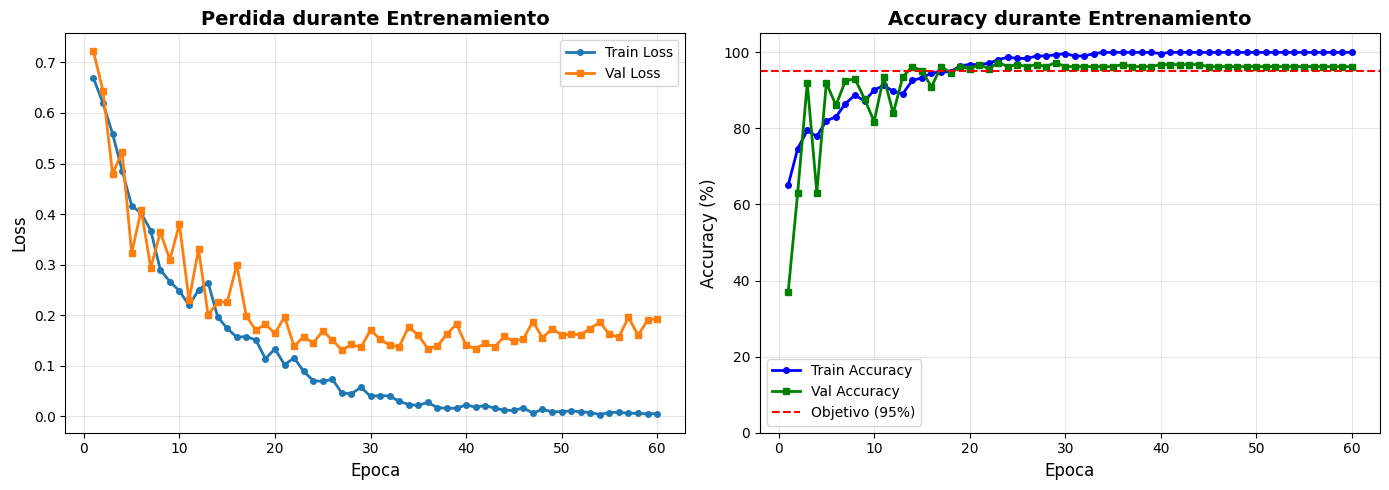

[OK] Grafica guardada: training_results.png


In [ ]:
# Graficar resultados del entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(range(1, epochs+1), train_losses, label='Train Loss',
         marker='o', linewidth=2, markersize=4)
ax1.plot(range(1, epochs+1), val_losses, label='Val Loss',
         marker='s', linewidth=2, markersize=4)
ax1.set_xlabel('Epoca', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Perdida durante Entrenamiento', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy (Train y Val)
ax2.plot(range(1, epochs+1), train_accuracies, label='Train Accuracy',
         marker='o', linewidth=2, markersize=4, color='blue')
ax2.plot(range(1, epochs+1), val_accuracies, label='Val Accuracy',
         marker='s', linewidth=2, markersize=4, color='green')
ax2.axhline(y=95, color='r', linestyle='--', label='Objetivo (95%)')
ax2.set_xlabel('Epoca', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy durante Entrenamiento', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("[OK] Grafica guardada: training_results.png")


De estas gráficas podemos ver que a partir del la época 30 la perdida de train sigue a la baja (el modelo sigue aprendiendo NO .. sino memorizando el dataset porque es muy pequeño) mientras que el loss de los datos de validation empieza a subir/bajar pero con tendencia al alza. Visto esto pensamos que existe un OVERFITING que podríamos evitar con alguna de estas 3 técnicas.
- 1.- Early stopping, detener el modelo de forma automática en cuanto veamos que ya no hay una reducción significativa en el loss, dando oportunidad a que el modelo aprenda PERO no memorize el dataset
- 2.- Regularización de la red neuronal, como hemos visto la red memoriza el dataset, para evitar eso podemos meter un dropout que significa que algunas conexiones entre las neuronas las cortamos, con ello la formamos a generaliza; evitando que memorice los pocos datos del dataset
- 3.- Como hemos dicho arriba, son pocos datos, así que otra técnica sería aplicar data augmentation que significa modificar minimamente las imagenes de tal forma que pacemos a tener en vez de 624 a lo mejor unas mas rotandolas, cosa que en el ambito industrial es muy recomendable, ya que las cámaras y la posición de las piezas siempre tienen variación en la vida del proyecto. Aplicar un poco de rotación no sería una idea descabellada.
- 4.- Cambia la arquitectura del la red, para que fuera un poco más sencilla, actualmente tiene 120 neuronas, tal vez con 60 podríamos probar.

**CONCLUSIÓN EL MODELO ESTA SOBRE AJUSTADO**

## 5. Evaluación en Conjunto de Test

Evaluación completa del modelo en el conjunto de test con métricas detalladas y comparación con validación.


## 5.1 Visualización de Predicciones Incorrectas

Mostrar las imágenes del conjunto de test que fueron clasificadas incorrectamente.



VISUALIZACION DE PREDICCIONES INCORRECTAS

Total de errores en test: 1
Total de muestras en test: 125
Accuracy: 99.20%


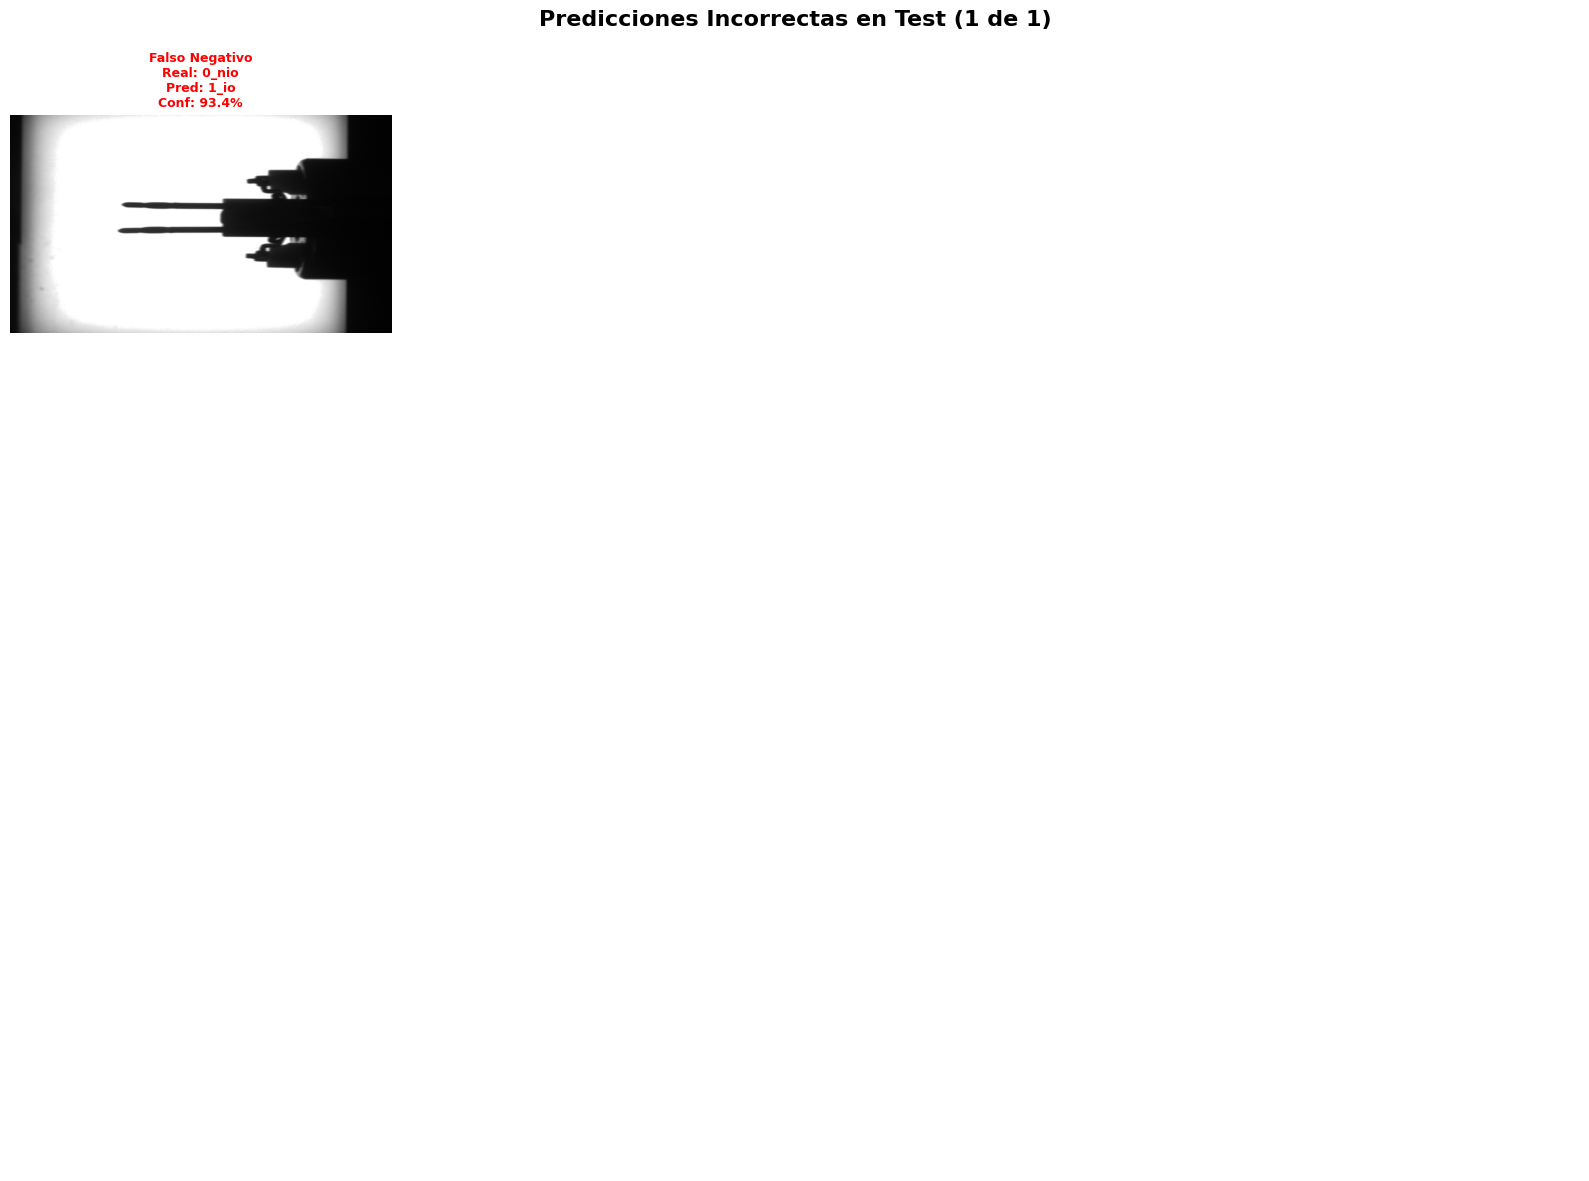


[OK] Visualizacion guardada: incorrect_predictions_test.png

ESTADISTICAS DE ERRORES

Falsos Negativos (NOK predicho como OK): 1
Falsos Positivos (OK predicho como NOK): 0


In [ ]:
# Visualizar predicciones incorrectas en test
print("\n" + "="*70)
print("VISUALIZACION DE PREDICCIONES INCORRECTAS")
print("="*70)

# Prepare datasets and dataloaders for testing
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformaciones (segun articulo)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((400, 700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Cargar dataset de test
test_dataset = datasets.ImageFolder(
    root='data/Coil_Vision/test',
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Obtener rutas de imagenes y predicciones incorrectas
incorrect_images = []
incorrect_labels = []
incorrect_preds = []
incorrect_confidences = []

# Recorrer test dataset y encontrar errores
model.eval()
with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

        for i in range(len(labels)):
            if predicted[i].item() != labels[i].item():
                # Guardar imagen, etiqueta real, prediccion y confianza
                incorrect_images.append(images[i].cpu())
                incorrect_labels.append(labels[i].item())
                incorrect_preds.append(predicted[i].item())
                incorrect_confidences.append(confidence[i].item() * 100)

print(f"\nTotal de errores en test: {len(incorrect_images)}")
print(f"Total de muestras en test: {len(test_dataset)}")
print(f"Accuracy: {(len(test_dataset) - len(incorrect_images)) / len(test_dataset) * 100:.2f}%")

# Visualizar hasta 12 errores
n_show = min(12, len(incorrect_images))
if n_show > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(f'Predicciones Incorrectas en Test ({n_show} de {len(incorrect_images)})',
                 fontsize=16, fontweight='bold')

    for idx in range(n_show):
        row = idx // 4
        col = idx % 4

        # Desnormalizar imagen (invertir Normalize(mean=0.5, std=0.5))
        img = incorrect_images[idx].squeeze(0)
        img = (img * 0.5) + 0.5  # Desnormalizar: (x * std) + mean
        img = torch.clamp(img, 0, 1)

        axes[row, col].imshow(img, cmap='gray')

        real_label = test_dataset.classes[incorrect_labels[idx]]
        pred_label = test_dataset.classes[incorrect_preds[idx]]
        conf = incorrect_confidences[idx]

        # Determinar color segun tipo de error
        if incorrect_labels[idx] == 0:  # Real NOK, predicho como OK
            error_type = "Falso Negativo"
            color = 'red'
        else:  # Real OK, predicho como NOK
            error_type = "Falso Positivo"
            color = 'orange'

        title = f"{error_type}\nReal: {real_label}\nPred: {pred_label}\nConf: {conf:.1f}%"
        axes[row, col].set_title(title, fontsize=9, color=color, fontweight='bold')
        axes[row, col].axis('off')

    # Ocultar ejes vacios
    for idx in range(n_show, 12):
        row = idx // 4
        col = idx % 4
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('incorrect_predictions_test.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n[OK] Visualizacion guardada: incorrect_predictions_test.png")

    # Mostrar estadisticas de errores
    print("\n" + "="*70)
    print("ESTADISTICAS DE ERRORES")
    print("="*70)

    false_negatives = sum(1 for i in range(len(incorrect_labels))
                         if incorrect_labels[i] == 0)  # Real NOK, predicho OK
    false_positives = sum(1 for i in range(len(incorrect_labels))
                         if incorrect_labels[i] == 1)  # Real OK, predicho NOK

    print(f"\nFalsos Negativos (NOK predicho como OK): {false_negatives}")
    print(f"Falsos Positivos (OK predicho como NOK): {false_positives}")
    print("="*70)
else:
    print("\n[OK] No hay errores - modelo perfecto en test!")
    print("Accuracy: 100%")

Como podemos ver es difícil de saber si es una pieza OK / NOK, también recordemos que que nuestro red neuronal tiene dos salidas OK  y  NOK  pero están clasificación la hace con un umbral de probabilidad que por default es de 0.5.
- Si la probabilidad >= Umbral, el modelo dice Clase Positiva OK
- Si la probabilidad < Umbral, el modelo dice Clase Negativa NOK
En este caso:
1.- El modelo calculó que la probabilidad de que esta imagen fuera OK era del 93.4%
2.- Como 93.4% es mayor que el umbral de 50% el modelo predijo correctamente OK
3.- Pero la etiqueta real era NOK  (0_nio)
El modelo estaba muy seguro de su predicción, pero aún así se equivoco.

EVALUACION EN CONJUNTO DE TEST

Dataset de test: 125 imagenes
Clases: ['0_nio', '1_io']

METRICAS DE TEST

Test Loss: 0.0249
Test Accuracy: 99.20%

Metricas promedio (weighted):
  Precision: 99.21%
  Recall: 99.20%
  F1-Score: 99.19%

Metricas por clase:

  0_nio:
    Precision: 100.00%
    Recall: 96.00%
    F1-Score: 97.96%
    Support: 25 muestras

  1_io:
    Precision: 99.01%
    Recall: 100.00%
    F1-Score: 99.50%
    Support: 100 muestras

COMPARACION: VALIDACION vs TEST

Metrica              Validacion      Test            Diferencia     
----------------------------------------------------------------------
Loss                 0.1929          0.0249          0.1680         
Accuracy (%)         96.26           99.20           2.94           


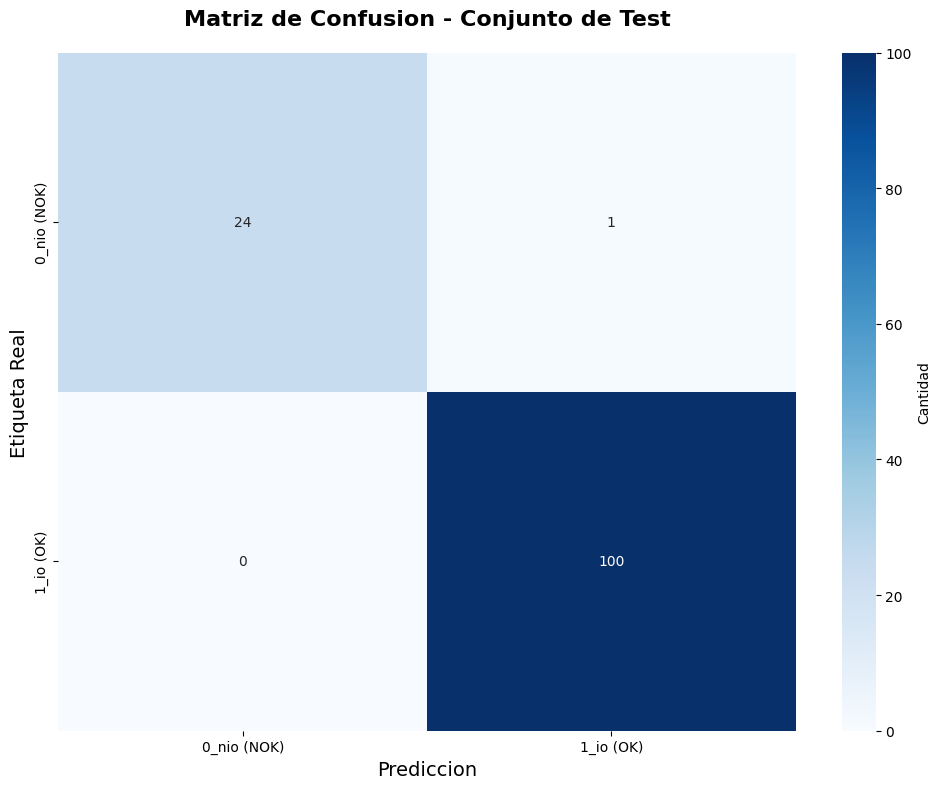


[OK] Matriz de confusion guardada: confusion_matrix_test.png

REPORTE DE CLASIFICACION (TEST)
              precision    recall  f1-score   support

 0_nio (NOK)     1.0000    0.9600    0.9796        25
   1_io (OK)     0.9901    1.0000    0.9950       100

    accuracy                         0.9920       125
   macro avg     0.9950    0.9800    0.9873       125
weighted avg     0.9921    0.9920    0.9919       125



In [ ]:
# Evaluacion completa en conjunto de test
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print("="*70)
print("EVALUACION EN CONJUNTO DE TEST")
print("="*70)

# Cargar dataset de test
test_dataset = datasets.ImageFolder(
    root='data/Coil_Vision/test',
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

print(f"\nDataset de test: {len(test_dataset)} imagenes")
print(f"Clases: {test_dataset.classes}")

# Evaluar en test
model.eval()
test_labels = []
test_preds = []
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(predicted.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_accuracy = accuracy_score(test_labels, test_preds) * 100

# Calcular metricas por clase
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0
)

# Metricas promedio
precision_avg = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted', zero_division=0
)[0] * 100
recall_avg = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted', zero_division=0
)[1] * 100
f1_avg = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted', zero_division=0
)[2] * 100

print("\n" + "="*70)
print("METRICAS DE TEST")
print("="*70)
print(f"\nTest Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"\nMetricas promedio (weighted):")
print(f"  Precision: {precision_avg:.2f}%")
print(f"  Recall: {recall_avg:.2f}%")
print(f"  F1-Score: {f1_avg:.2f}%")

print(f"\nMetricas por clase:")
for i, class_name in enumerate(test_dataset.classes):
    print(f"\n  {class_name}:")
    print(f"    Precision: {precision[i]*100:.2f}%")
    print(f"    Recall: {recall[i]*100:.2f}%")
    print(f"    F1-Score: {f1[i]*100:.2f}%")
    print(f"    Support: {support[i]} muestras")

print("="*70)

# Comparacion con validacion
print("\n" + "="*70)
print("COMPARACION: VALIDACION vs TEST")
print("="*70)
print(f"\n{'Metrica':<20} {'Validacion':<15} {'Test':<15} {'Diferencia':<15}")
print("-"*70)
print(f"{'Loss':<20} {val_losses[-1]:<15.4f} {avg_test_loss:<15.4f} {abs(val_losses[-1]-avg_test_loss):<15.4f}")
print(f"{'Accuracy (%)':<20} {val_accuracies[-1]:<15.2f} {test_accuracy:<15.2f} {abs(val_accuracies[-1]-test_accuracy):<15.2f}")
print("="*70)

# Matriz de confusion
cm = confusion_matrix(test_labels, test_preds)

# Visualizar matriz de confusion
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'{test_dataset.classes[0]} (NOK)', f'{test_dataset.classes[1]} (OK)'],
            yticklabels=[f'{test_dataset.classes[0]} (NOK)', f'{test_dataset.classes[1]} (OK)'],
            cbar_kws={'label': 'Cantidad'})
plt.title('Matriz de Confusion - Conjunto de Test', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=14)
plt.xlabel('Prediccion', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[OK] Matriz de confusion guardada: confusion_matrix_test.png")

# Reporte de clasificacion completo
print("\n" + "="*70)
print("REPORTE DE CLASIFICACION (TEST)")
print("="*70)
print(classification_report(test_labels, test_preds,
                           target_names=[f'{test_dataset.classes[0]} (NOK)',
                                        f'{test_dataset.classes[1]} (OK)'],
                           digits=4))
print("="*70)


Dependiendo de la relevancia del producto, estamos dejando pasar 1 pieza como OK cuando en realidad ha sido NOK.

La tradución de nuestra matriz:
* Verdadero Negativo (VN),"Modelo predice NOK, y la Realidad es NOK.","Fila 0, Columna 0",24
* Falso Positivo (FP),"Modelo predice OK, pero la Realidad es NOK.","Fila 0, Columna 1",1
* Falso Negativo (FN),"Modelo predice NOK, pero la Realidad es OK.","Fila 1, Columna 0",0
* Verdadero Positivo (VP),"Modelo predice OK, y la Realidad es OK.","Fila 1, Columna 1",100

## 6. Descargar Resultados


In [ ]:
# Descargar modelo y graficas
from google.colab import files
import os

print("Descargando archivos...")
files.download('models/vision_inspection_model.pth')
files.download('training_results.png')
files.download('confusion_matrix_test.png')

# Descargar visualizacion de errores si existe
if os.path.exists('incorrect_predictions_test.png'):
    files.download('incorrect_predictions_test.png')

print("[OK] Archivos descargados")


Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[OK] Archivos descargados


---

## Resumen Final

**Dataset:**
- 624 imagenes (500 OK + 124 NOK)
- Split (según artículo): 50% train / 30% val / 20% test
  - Train: ~312 imagenes (50%)
  - Val: ~187 imagenes (30%)
  - Test: ~125 imagenes (20%)

**Modelo:**
- 32M parametros
- 2 capas Conv + 2 capas FC
- Tiempo: ~60 minutos con GPU

**Resultado:**
- Val Accuracy final: ver celda anterior
- Test Accuracy final: ver celda anterior
- Objetivo del articulo: >95%

**Proximos pasos:**

1. Implementar GradCAM para visualizar decisiones
2. Experimentar con data augmentation, rotando las piezas tanto ok/nok y además hacer un drop out para que no generalice, volver a lanzar con 60 epocas.
3. Probar arquitecturas alternativas, tal vez más sencillas
4. Llevarlo a producción

**Referencia:** [Medium Article - Ingo Nowitzky](https://medium.com/data-science/building-a-vision-inspection-cnn-for-an-industrial-application-138936d7a34a)
